# `Введение в Эффективные Системы Машинного обучения`

## `Задание 01. Умножение векторов и матриц с использованием CUDA`.

#### Дьячковский Михаил:

Дата выдачи: <span style="color:red">__8 сентября__</span>.

Мягкий дедлайн: <span style="color:red">__21 сентября 05:00__</span>.

Стоимость: __10 баллов__ (основная часть заданий) + __3 балла__ (дополнительные задания).

<span style="color:red">__В ноутбуке все клетки должны выполняться без ошибок при последовательном их выполнении.__</span>

#### `Москва, 2026`

##### По всем вопросам писать `@trandelik`

## `Введение`

В рамках этого задания вам предстоит познакомиться с основами программирования на GPU, чтобы лучше разобраться в их устройстве. Для этого мы воспользуемся библиотекой Numba, которая позволяет писать CUDA-кернелы прямо на Python. Несмотря на это, опыт написания кернелов на Numba напрямую переносится на C++ CUDA в силу схожих интерфейсов, при этом требует более низкого порога входа.

Документация [Numba CUDA Guide](https://numba.readthedocs.io/en/stable/cuda/index.html)

При составлении задания авторы сильно вдохновлялись [GPU puzzles](https://github.com/srush/GPU-Puzzles)

**Важно:** авторы настоятельно рекомендуют выполнять домашнее задание в Google Colab и не гарантируют поддержку других сред. Также мы приведем версии CUDA, драйверов, python и библиотек ниже.

In [ ]:
!nvidia-smi

Sat Sep 19 12:24:02 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   50C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


## `Setup`

In [ ]:
!pip install -U "numba-cuda[cu12]>=0.22.2,<0.23.0"


from numba import config
config.CUDA_ENABLE_PYNVJITLINK = 1

In [ ]:
import numba
from numba import cuda
import numpy as np
import torch
import timeit
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys

warnings.filterwarnings(
    action="ignore", category=numba.NumbaPerformanceWarning, module="numba"
)

sns.set_theme(style="whitegrid")
%config InlineBackend.figure_format = 'svg'

In [ ]:
print("Python version:", sys.version)
print("Numba version:", numba.__version__)
print("Numpy version:", np.__version__)
print("Torch version:", torch.__version__)

Python version: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
Numba version: 0.61.2
Numpy version: 2.1.3
Torch version: 2.11.0+cu128


## `Часть 1. Скалярное произведение векторов (4 балла)`

### `Testing Utils`

Мы подготовили тестовую функцию, которая поможет проверить корректность ваших реализаций и измерить их производительность. Она будет собирать данные о времени выполнения, чтобы мы могли построить красивые графики.

In [ ]:
dot_product_results = []

def test_dot_product(custom_function, name, full_bench=True):
    print(f"--- Testing: {name} ---")
    # Test 1: Простой тест для векторов
    a = np.array([1, 2, 3], dtype=np.float32)
    b = np.array([4, 5, 6], dtype=np.float32)
    expected = a @ b
    result = custom_function(a, b)
    assert np.allclose(result, expected), f"Test 1 failed: {result} != {expected}"

    # Test 2: Тест с нулевым вектором
    z = np.zeros(5, dtype=np.float32)
    c = np.array([1, 2, 3, 4, 5], dtype=np.float32)
    expected = z @ c
    result = custom_function(z, c)
    assert np.allclose(result, expected), f"Test 2 failed: {result} != {expected}"

    # Test 3: Случайные векторы разных размеров
    shapes = [10, 101, 1000]
    for i, shape in enumerate(shapes):
        np.random.seed(i)
        a = np.random.rand(shape).astype(np.float32)
        b = np.random.rand(shape).astype(np.float32)
        expected = a @ b
        result = custom_function(a, b)
        assert np.allclose(result, expected, atol=1e-5), f"Test 3 (shape={shape}) failed"
    print("All tests passed!")

    # Бенчмарки
    print("Benchmarking...")
    sizes = [1_000, 10_000, 100_000, 1_000_000]
    if full_bench:
        sizes.append(10_000_000)

    for size in sizes:
        np.random.seed(42)
        a = np.random.rand(size).astype(np.float32)
        b = np.random.rand(size).astype(np.float32)

        # Прогрев (первый запуск может быть медленным из-за компиляции)
        custom_function(a,b)

        times = timeit.repeat(lambda: custom_function(a, b), number=10, repeat=3)
        times = np.array(times)
        mean_time = times.mean()
        std_time = times.std()

        dot_product_results.append({
            "name": name,
            "size": size,
            "mean_time": mean_time,
            "std_time": std_time
        })
        print(f"Size={size}:\t{mean_time:.6f} ± {std_time:.6f} seconds")
    print("Done.\n")

### `Baselines`

In [ ]:
def naive_dot(a, b):
    result = np.float32(0.0)
    for i in range(a.shape[0]):
        result += a[i] * b[i]
    return result

def numpy_dot(a, b):
    return a @ b

def torch_dot(a, b):
    # Мы живем в мире "посчитай скалярное произведение этих двух numpy векторов"
    # Поэтому время перекладывания на GPU тоже надо учитывать
    a_device = torch.from_numpy(a).cuda()
    b_device = torch.from_numpy(b).cuda()
    result_cuda = torch.dot(a_device, b_device)
    return result_cuda.cpu().numpy()

In [ ]:
test_dot_product(naive_dot, "Python Loop", full_bench=False)
test_dot_product(numpy_dot, "Numpy")
test_dot_product(torch_dot, "PyTorch")

--- Testing: Python Loop ---
All tests passed!
Benchmarking...
Size=1000:	0.003048 ± 0.000345 seconds
Size=10000:	0.029640 ± 0.002015 seconds
Size=100000:	0.711732 ± 0.218029 seconds
Size=1000000:	4.956170 ± 2.783881 seconds
Done.

--- Testing: Numpy ---
All tests passed!
Benchmarking...
Size=1000:	0.000024 ± 0.000003 seconds
Size=10000:	0.000029 ± 0.000003 seconds
Size=100000:	0.000147 ± 0.000013 seconds
Size=1000000:	0.003457 ± 0.000215 seconds
Size=10000000:	0.051248 ± 0.000747 seconds
Done.

--- Testing: PyTorch ---
All tests passed!
Benchmarking...
Size=1000:	0.000856 ± 0.000051 seconds
Size=10000:	0.001116 ± 0.000028 seconds
Size=100000:	0.003349 ± 0.000102 seconds
Size=1000000:	0.018885 ± 0.000622 seconds
Size=10000000:	0.180643 ± 0.001195 seconds
Done.



### `Задание 1. Naive GPU implementation (1 балл)`

Наша первая задача — реализовать скалярное произведение на GPU.

Здесь мы поручим каждому потоку вычислить произведение одной пары элементов `a[i] * b[i]`. Затем все эти произведения нужно как-то сложить. Самый простой способ — использовать [**атомарную операцию**](https://habr.com/ru/articles/244881/). Для этого предлагается использовать функцию `cuda.atomic.add(array, index, value)`.

In [ ]:
THREADS_PER_BLOCK = 1024

@cuda.jit
def naive_dot_product_kernel(a, b, result):
    '''
    Кернел, вычисляющий скалярное произведение векторов a и b и
    записывающий его в нулевую позицию вектора result.
    Для вычисления суммы используется atomic.add
    '''
    idx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    if idx < a.shape[0]:
      cuda.atomic.add(result, 0, a[idx] * b[idx])


def dot_product_naive_gpu(a, b):
    '''
    Функция, принимающая на вход два numpy массива и вычисляющая их скалярное произведение,
    используя naive_dot_product_kernel
    '''
    # Создаем на CPU массив для хранения результата
    result = np.zeros(1, dtype=np.float32)

    # Копируем данные на GPU
    device_a = cuda.to_device(a)
    device_b = cuda.to_device(b)
    device_result = cuda.to_device(result)

    # Вычисляем, сколько блоков нам нужно для всех элементов вектора
    blocks_per_grid = (a.shape[0] + (THREADS_PER_BLOCK - 1)) // THREADS_PER_BLOCK

    # Запускаем кернел
    naive_dot_product_kernel[blocks_per_grid, THREADS_PER_BLOCK](device_a, device_b, device_result)

    # Копируем результат обратно на CPU
    result_host = device_result.copy_to_host()

    return result_host[0]

In [ ]:
test_dot_product(dot_product_naive_gpu, "Naive GPU")

--- Testing: Naive GPU ---
All tests passed!
Benchmarking...
Size=1000:	0.013277 ± 0.000582 seconds
Size=10000:	0.011990 ± 0.000271 seconds
Size=100000:	0.018092 ± 0.000757 seconds
Size=1000000:	0.070729 ± 0.001197 seconds
Size=10000000:	0.436664 ± 0.031218 seconds
Done.



### `Задание 2. Smarter GPU implementation with Shared Memory (1 балл)`

Прошлая реализация проста, но крайне неэффективна. Атомарные операции создают "бутылочное горлышко", заставляя все потоки синхронизироваться при записи в глобальную память.

Чтобы это исправить, мы воспользуемся `shared memory` — сверхбыстрой памятью, доступной для всех потоков **внутри одного блока**. Алгоритм будет таким:

1.  Каждый поток вычисляет свое произведение `a[idx] * b[idx]`.
2.  Результат сохраняется в массив `s_data` в `shared memory`.
3.  **Синхронизируем все потоки в блоке** с помощью `cuda.syncthreads()`. Это гарантия того, что все потоки закончили шаг 2, прежде чем кто-то перейдет к шагу 4.
4.  Один поток (например, с `local_idx == 0`) проходит по всему массиву `s_data` и суммирует его значения.
5.  Этот же поток атомарно добавляет сумму своего блока к общему результату в глобальной памяти.

Теперь у нас всего одна синхронизация на блок, а не на каждый элемент, что должно быть гораздо быстрее.

In [ ]:
THREADS_PER_BLOCK = 1024

@cuda.jit
def shmem_dot_product_kernel(a, b, result):
    '''
    Кернел, вычисляющий скалярное произведение векторов a и b и
    записывающий его в нулевую позицию вектора result.
    Для вычисления суммы используется shared memory
    и последующее суммирование значений одним потоком
    '''
    # Создаем массив в shared memory
    s_data = cuda.shared.array(shape=THREADS_PER_BLOCK, dtype=numba.float32)

    # Глобальный и локальный (внутри блока) индексы
    global_idx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    local_idx = cuda.threadIdx.x

    # 1. Каждый поток считает произведение и записывает в shared memory
    if global_idx < a.shape[0]:
      s_data[local_idx] = a[global_idx] * b[global_idx]
    else:
      s_data[local_idx] = 0
    cuda.syncthreads()

    # 2. Один поток (нулевой) суммирует все, что есть в shared memory,
    # и атомарно добавляет к итоговому результату.
    if local_idx == 0:
      idx = THREADS_PER_BLOCK - 1
      while idx > 0:
        s_data[0] += s_data[idx]
        idx -= 1
      cuda.atomic.add(result, 0, s_data[0])


def dot_product_shmem(a, b):
    '''
    Функция, принимающая на вход два numpy массива и вычисляющая их скалярное произведение,
    используя shmem_dot_product_kernel
    '''
    result = np.zeros(1, dtype=np.float32)

    device_a = cuda.to_device(a)
    device_b = cuda.to_device(b)
    device_result = cuda.to_device(result)

    blocks_per_grid = (a.shape[0] + (THREADS_PER_BLOCK - 1)) // THREADS_PER_BLOCK
    shmem_dot_product_kernel[blocks_per_grid, THREADS_PER_BLOCK](device_a, device_b, device_result)
    cuda.synchronize()

    result_host = device_result.copy_to_host()
    return result_host[0]
    ### Аналогично функции из прошлого пункта

In [ ]:
test_dot_product(dot_product_shmem, "Shared Memory")

--- Testing: Shared Memory ---
All tests passed!
Benchmarking...
Size=1000:	0.006898 ± 0.000439 seconds
Size=10000:	0.007073 ± 0.000140 seconds
Size=100000:	0.010188 ± 0.000382 seconds
Size=1000000:	0.031718 ± 0.001078 seconds
Size=10000000:	0.215995 ± 0.002615 seconds
Done.



### `Задание 3. Even More Smart GPU implementation with Parallel Reduction (2 балла)`

В предыдущем решении мы добились ускорения, но суммирование внутри блока все еще выполнялось в один поток. Это неэффективно. Ключевая особенность CUDA — параллельность, и мы можем использовать ее даже для суммирования!

Для этого применяется алгоритм **параллельной редукции (parallel reduction)**. Идея в том, чтобы на каждой итерации складывать пары элементов, уменьшая массив вдвое, пока не останется один элемент — сумма.

Пример для 8 элементов:
1.  `[1, 2, 3, 4, 5, 6, 7, 8]`
2.  Потоки 0-3 складывают элементы с потоками 4-7: `s_data[i] += s_data[i + 4]`.
    Результат: `[6, 8, 10, 12, ...]`
3.  Потоки 0-1 складывают элементы с потоками 2-3: `s_data[i] += s_data[i + 2]`.
    Результат: `[16, 20, ...]`
4.  Поток 0 складывает элемент с потоком 1: `s_data[0] += s_data[1]`.
    Результат: `[36, ...]`

In [ ]:
THREADS_PER_BLOCK = 1024

@cuda.jit
def reduce_dot_product_kernel(a, b, result):
    '''
    Кернел, вычисляющий скалярное произведение векторов a и b и
    записывающий его в нулевую позицию вектора result.
    Для вычисления суммы используется shared memory
    и алгоритм параллельной редукции
    '''

    # 1. Загружаем данные в shared memory (как в прошлом задании)
    s_data = cuda.shared.array(shape=THREADS_PER_BLOCK, dtype=numba.float32)
    global_idx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    local_idx = cuda.threadIdx.x

    # 2. Реализуем параллельную редукцию.
    if global_idx < a.shape[0]:
      s_data[local_idx] = a[global_idx] * b[global_idx]
    else:
      s_data[local_idx] = 0
    cuda.syncthreads()

    stride = cuda.blockDim.x // 2
    while stride > 0:
      if local_idx < stride:
        s_data[local_idx] = s_data[local_idx] + s_data[local_idx + stride]
      cuda.syncthreads()
      stride //= 2

    # 3. Нулевой поток записывает итоговую сумму
    if local_idx == 0:
      cuda.atomic.add(result, 0, s_data[local_idx])


def dot_product_reduce(a, b):
    '''
    Функция, принимающая на вход два numpy массива и вычисляющая их скалярное произведение,
    используя reduce_dot_product_kernel
    '''
    result = np.zeros(1, dtype=np.float32)

    device_a = cuda.to_device(a)
    device_b = cuda.to_device(b)
    device_result = cuda.to_device(result)

    blocks_per_grid = (a.shape[0] + (THREADS_PER_BLOCK - 1)) // THREADS_PER_BLOCK
    reduce_dot_product_kernel[blocks_per_grid, THREADS_PER_BLOCK](device_a, device_b, device_result)
    cuda.synchronize()

    result_host = device_result.copy_to_host()
    return result_host[0]

In [ ]:
test_dot_product(dot_product_reduce, "Parallel Reduce")

--- Testing: Parallel Reduce ---
All tests passed!
Benchmarking...
Size=1000:	0.007528 ± 0.000666 seconds
Size=10000:	0.007416 ± 0.001050 seconds
Size=100000:	0.009490 ± 0.000398 seconds
Size=1000000:	0.029551 ± 0.000289 seconds
Size=10000000:	0.207054 ± 0.002118 seconds
Done.



### `Сравнение результатов`

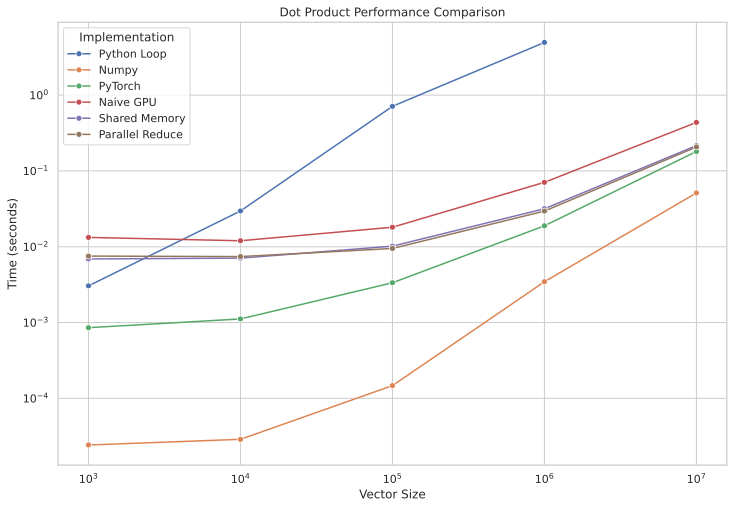

In [ ]:
df_dot = pd.DataFrame(dot_product_results)

plt.figure(figsize=(12, 8))
sns.lineplot(data=df_dot, x='size', y='mean_time', hue='name', marker='o')
plt.title('Dot Product Performance Comparison')
plt.xlabel('Vector Size')
plt.ylabel('Time (seconds)')
plt.xscale('log')
plt.yscale('log')
plt.legend(title='Implementation')
plt.show()

**Выводы**:

Numpy быстрее всех, так как внутренне использует C и C++ код в своем ядре и нативно использует векторизованные вычисления. И ему не надо переносить числа на GPU.

Pytorch скорее всего в пределе даже быстрее Numpy(клянусь, когда заполнял выводы части 1, я еще даже не заглядывал дальше, где моя гипотеза доказывается реальными замерами), так как тоже максимально оптимизирован под GPU при помощи CUDA ядер на C++, но ему нужно перенести числа с CPU на GPU и обратно.

Parallel Reduce в моем исполнении, наверное, на идейном уровне всё равно что torch.dot за исключением кода на Python.

Каждое ухищрение с оптимизацией CUDA ядер улучшает скорость. Что логично)

## `Часть 2. Перемножение матриц (6 баллов)`

### `Testing utils`

In [ ]:
matmul_results = []

def test_matrix_multiplication(custom_function, name, full_bench=True):
    print(f"--- Testing: {name} ---")

    # Test 1: Простые 2x2 матрицы
    A = np.array([[1, 2], [3, 4]], dtype=np.float32)
    B = np.array([[5, 6], [7, 8]], dtype=np.float32)
    expected = A @ B
    result = custom_function(A, B)
    assert np.allclose(result, expected), f"Test 1 failed: \n{result} \n!= \n{expected}"

    # Test 2: Умножение на единичную матрицу
    I = np.eye(3, dtype=np.float32)
    C = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]], dtype=np.float32)
    expected = I @ C
    result = custom_function(I, C)
    assert np.allclose(result, expected), f"Test 2 failed"

    # Test 3: Неквадратные матрицы
    A = np.array([[1, 2, 3], [4, 5, 6]], dtype=np.float32) # 2x3
    B = np.array([[7, 8], [9, 10], [11, 12]], dtype=np.float32) # 3x2
    expected = A @ B
    result = custom_function(A, B)
    assert np.allclose(result, expected), f"Test 3 failed"

    # Test 4: Случайные матрицы
    shapes = [(13, 5, 17), (32, 64, 32), (100, 100, 100)]
    for i, (M, K, N) in enumerate(shapes):
        np.random.seed(i)
        A = np.random.rand(M, K).astype(np.float32)
        B = np.random.rand(K, N).astype(np.float32)
        expected = A @ B
        result = custom_function(A, B)
        assert np.allclose(result, expected, atol=1e-5), f"Test 4 failed for shape {(M,K,N)}"

    print("All tests passed!")

    # Бенчмарки
    print("Benchmarking...")
    sizes = [32, 64]
    if full_bench:
        sizes.extend([128, 256, 512, 1024, 2048, 4096])

    for size in sizes:
        np.random.seed(42)
        A = np.random.rand(size, size).astype(np.float32)
        B = np.random.rand(size, size).astype(np.float32)

        custom_function(A, B) # Прогрев

        times = timeit.repeat(lambda: custom_function(A, B), number=10, repeat=3)
        times = np.array(times)
        mean_time = times.mean()
        std_time = times.std()

        matmul_results.append({
            "name": name,
            "size": size,
            "mean_time": mean_time,
            "std_time": std_time
        })
        print(f"Size={size}x{size}:\t{mean_time:.6f} ± {std_time:.6f} seconds")
    print("Done.\n")

### `Baselines`

In [ ]:
def naive_matmul(A, B):
    result = np.zeros((A.shape[0], B.shape[1]), dtype=np.float32)
    for i in range(A.shape[0]):
        for j in range(B.shape[1]):
            for k in range(A.shape[1]):
                result[i, j] += A[i, k] * B[k, j]
    return result

def numpy_matmul(A, B):
    return A @ B

def torch_matmul(A, B):
    A_device = torch.from_numpy(A).cuda()
    B_device = torch.from_numpy(B).cuda()
    result_cuda = A_device @ B_device
    return result_cuda.cpu().numpy()

In [ ]:
test_matrix_multiplication(naive_matmul, "Python Loop", full_bench=False)
test_matrix_multiplication(numpy_matmul, "Numpy")
test_matrix_multiplication(torch_matmul, "PyTorch")

--- Testing: Python Loop ---
All tests passed!
Benchmarking...
Size=32x32:	0.186034 ± 0.003163 seconds
Size=64x64:	1.636202 ± 0.229072 seconds
Done.

--- Testing: Numpy ---
All tests passed!
Benchmarking...
Size=32x32:	0.000047 ± 0.000032 seconds
Size=64x64:	0.000058 ± 0.000003 seconds
Size=128x128:	0.000541 ± 0.000033 seconds
Size=256x256:	0.003173 ± 0.000156 seconds
Size=512x512:	0.025145 ± 0.001904 seconds
Size=1024x1024:	0.188744 ± 0.017377 seconds
Size=2048x2048:	1.922549 ± 0.443677 seconds
Size=4096x4096:	12.499539 ± 0.153367 seconds
Done.

--- Testing: PyTorch ---
All tests passed!
Benchmarking...
Size=32x32:	0.001402 ± 0.000244 seconds
Size=64x64:	0.001578 ± 0.000162 seconds
Size=128x128:	0.002164 ± 0.000114 seconds
Size=256x256:	0.005286 ± 0.000475 seconds
Size=512x512:	0.012594 ± 0.000587 seconds
Size=1024x1024:	0.038048 ± 0.000805 seconds
Size=2048x2048:	0.160865 ± 0.009524 seconds
Size=4096x4096:	0.987786 ± 0.010745 seconds
Done.



### `Задание 4. Dot product based solution (1 балл)`

Каждый элемент `C[i, j]` результирующей матрицы `C` является скалярным произведением i-й строки матрицы `A` и j-го столбца матрицы `B`. У нас уже есть быстрая реализация скалярного произведения с помощью `dot_product_reduce`. Давайте воспользуемся ей.

In [ ]:
THREADS_PER_BLOCK = 1024

def matmul_dot_based_gpu(A, B):
    '''
    Функция, вычисляющая произведение матриц A и B путем вычисления
    скалярных произведений с помощью dot_product_reduce
    '''
    M, K = A.shape
    K, N = B.shape
    C = np.empty((M, N), dtype=A.dtype)
    B_T = np.ascontiguousarray(B.T)

    idx = 0
    while idx < M * N:
      j = idx % N
      i = idx // N
      C[i, j] = dot_product_reduce(A[i, :], B_T[j, :])
      idx += 1

    return C

In [ ]:
test_matrix_multiplication(matmul_dot_based_gpu, "Dot-based GPU", full_bench=False)

--- Testing: Dot-based GPU ---
All tests passed!
Benchmarking...
Size=32x32:	6.979298 ± 0.369722 seconds
Size=64x64:	27.402811 ± 0.058039 seconds
Done.



### `Задание 5. A better way: one kernel for the whole matrix (2 балла)`

**Проблема:** Прошлый подход ужасно неэффективен. На каждый элемент `C[i, j]` мы будем заново запускать CUDA-кернел. Запуск кернела — дорогая операция. Мы делаем `M*N` запусков, каждый из которых несет большие накладные расходы.

Давайте напишем один кернел, который вычислит всю матрицу `C` за один раз.

Для этого мы будем использовать **двумерный грид блоков и двумерные блоки потоков**. Каждому потоку мы поручим вычислить ровно один элемент `C[i,j]` результирующей матрицы.

In [ ]:
THREADS_PER_BLOCK_2D = (32, 32)

@cuda.jit
def matmul_kernel(A, B, C):
    '''
    Кернел, вычисляющий произведение матриц A и B и
    записывающий его в матрицу C.
    Для вычисления произведения каждый поток вычисляет C[i, j] элемент матрицы C
    '''

    # 1. Получаем глобальные индексы (i, j) для результирующей матрицы C
    col = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    row = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y

    # 2. Вычисляем скалярное произведение A[i, :] и B[:, j]
    if col < C.shape[1] and row < C.shape[0]:
      dot_product = numba.float32(0.0)
      for k in range(A.shape[1]):
        dot_product += A[row, k] * B[k, col]
      C[row, col] = dot_product


def matmul_naive_gpu(A, B):
    '''
    Функция, принимающая на вход два 2D numpy массива и вычисляющая их произведение,
    используя matmul_kernel
    '''
    # Аллоцируем память под результат
    C = np.zeros((A.shape[0], B.shape[1]), dtype=np.float32)

    # Копируем данные на GPU
    device_A = cuda.to_device(A)
    device_B = cuda.to_device(B)
    device_C = cuda.to_device(C)

    # Вычисляем размер сетки
    blocks_per_grid_x = (B.shape[1] + (THREADS_PER_BLOCK_2D[0] - 1)) // THREADS_PER_BLOCK_2D[0]
    blocks_per_grid_y = (A.shape[0] + (THREADS_PER_BLOCK_2D[1] - 1)) // THREADS_PER_BLOCK_2D[1]
    blocks_per_grid_2d = (blocks_per_grid_x, blocks_per_grid_y)

    # Запускаем kernel
    matmul_kernel[blocks_per_grid_2d, THREADS_PER_BLOCK_2D](device_A, device_B, device_C)

    # Возвращаем результат
    return device_C.copy_to_host()

In [ ]:
test_matrix_multiplication(matmul_naive_gpu, "Naive Matmul GPU")

--- Testing: Naive Matmul GPU ---
All tests passed!
Benchmarking...
Size=32x32:	0.007119 ± 0.000661 seconds
Size=64x64:	0.008023 ± 0.001136 seconds
Size=128x128:	0.008696 ± 0.000749 seconds
Size=256x256:	0.013304 ± 0.000301 seconds
Size=512x512:	0.045737 ± 0.000821 seconds
Size=1024x1024:	0.146356 ± 0.026458 seconds
Size=2048x2048:	0.879615 ± 0.008053 seconds
Size=4096x4096:	6.794554 ± 0.079913 seconds
Done.



### `Задание 6. Efficient Matmul with Tiling (3 балла)`

Предыдущее решение работает, но оно все еще неоптимально. Главный недостаток — огромное количество **повторных чтений из глобальной памяти**. Каждый поток, вычисляющий `C[i, j]`, читает всю i-ю строку `A` и весь j-й столбец `B`. При этом соседний поток, вычисляющий `C[i, j+1]`, будет заново читать ту же самую i-ю строку `A`.

Чтение из глобальной памяти — самая медленная операция на GPU. Чтобы ее минимизировать, мы применим **тайловое умножение (tiled matrix multiplication)**.

**Алгоритм:**

1.  Мысленно разбиваем матрицы A и B на небольшие подматрицы (тайлы), размером с блок потоков (например, 16x16).
2.  **Блок потоков** совместно загружает один тайл из матрицы `A` и один тайл из матрицы `B` в быструю **`shared memory`**.
3.  **Синхронизация.** Ждем, пока все потоки блока закончат загрузку.
4.  Каждый поток в блоке вычисляет часть своего итогового значения `C[i,j]`, используя **только данные из `shared memory`**. Это очень быстро.
5.  Повторяем шаги 2-4 для всех пар тайлов, которые влияют на результирующий тайл матрицы `C`, и накапливаем сумму в локальной переменной (регистре).
6.  В самом конце каждый поток записывает накопленное значение в `C[i, j]` в глобальную память.

Таким образом, каждый элемент матриц A и B загружается из глобальной памяти всего один раз за итерацию по тайлам, а затем многократно переиспользуется из сверхбыстрой `shared memory`.

![Tiled Matrix Multiplication](https://cnugteren.github.io/tutorial/images/gemm2a.png)

In [ ]:
TILE_SIZE = 32


@cuda.jit
def efficient_matmul_kernel(A, B, C):
    '''
    Кернел, вычисляющий произведение матриц A и B и
    записывающий его в матрицу C.
    Для вычисления произведения используется tiled matrix multiplication алгоритм
    '''
    # 1. Объявляем тайлы в shared memory и вычисляем индексы
    global_col = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    global_row = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y
    local_col = cuda.threadIdx.x
    local_row = cuda.threadIdx.y

    A_tile = cuda.shared.array(shape=(TILE_SIZE, TILE_SIZE), dtype=numba.float32)
    B_tile = cuda.shared.array(shape=(TILE_SIZE, TILE_SIZE), dtype=numba.float32)

    # 2. Переменная-аккумулятор для хранения частичной суммы C[i,j] (в регистрах)
    accumulator = np.float32(0.0)

    # 3. Проходим по тайлам матриц A и B
    n_tiles = (A.shape[1] + (TILE_SIZE - 1)) // TILE_SIZE
    for tile in range(n_tiles):
        # 4. Каждый поток загружает один элемент из глобальной памяти в shared memory,
        # если индексы корректны
        tile_col = tile * TILE_SIZE + local_col
        tile_row = tile * TILE_SIZE + local_row

        if global_row < A.shape[0] and tile_col < A.shape[1]:
          A_tile[local_row, local_col] = A[global_row, tile_col]
        else:
          A_tile[local_row, local_col] = 0.0
        if tile_row < B.shape[0] and global_col < B.shape[1]:
          B_tile[local_row, local_col] = B[tile_row, global_col]
        else:
          B_tile[local_row, local_col] = 0.0
        cuda.syncthreads()

        # 5. Вычисляем произведение загруженных тайлов, результат накапливаем в `accumulator`
        k = 0
        while k < TILE_SIZE:
          accumulator += A_tile[local_row, k] * B_tile[k, local_col]
          k += 1
        cuda.syncthreads()

    # 6. Записываем результат в глобальную память
    if global_row < C.shape[0] and global_col < C.shape[1]:
      C[global_row, global_col] = accumulator


def efficient_matmul(A, B):
    '''
    Функция, принимающая на вход два 2D numpy массива и вычисляющая их  произведение,
    используя efficient_matmul_kernel
    '''
    ### Аналогично функции из прошлого пункта
    C = np.zeros((A.shape[0], B.shape[1]), dtype=np.float32)

    # Копируем данные на GPU
    device_A = cuda.to_device(A)
    device_B = cuda.to_device(B)
    device_C = cuda.to_device(C)

    # Вычисляем размер сетки
    blocks_per_grid_x = (B.shape[1] + (TILE_SIZE - 1)) // TILE_SIZE
    blocks_per_grid_y = (A.shape[0] + (TILE_SIZE - 1)) // TILE_SIZE
    blocks_per_grid_2d = (blocks_per_grid_x, blocks_per_grid_y)

    # Запускаем kernel
    efficient_matmul_kernel[blocks_per_grid_2d, (TILE_SIZE, TILE_SIZE)](device_A, device_B, device_C)

    # Возвращаем результат
    return device_C.copy_to_host()

In [ ]:
test_matrix_multiplication(efficient_matmul, "Tiled Matmul GPU")

--- Testing: Tiled Matmul GPU ---
All tests passed!
Benchmarking...
Size=32x32:	0.007715 ± 0.000479 seconds
Size=64x64:	0.007050 ± 0.000004 seconds
Size=128x128:	0.007647 ± 0.000214 seconds
Size=256x256:	0.010678 ± 0.000134 seconds
Size=512x512:	0.025168 ± 0.000538 seconds
Size=1024x1024:	0.079179 ± 0.000809 seconds
Size=2048x2048:	0.387332 ± 0.004879 seconds
Size=4096x4096:	2.587311 ± 0.008911 seconds
Done.



### `Сравнение результатов`

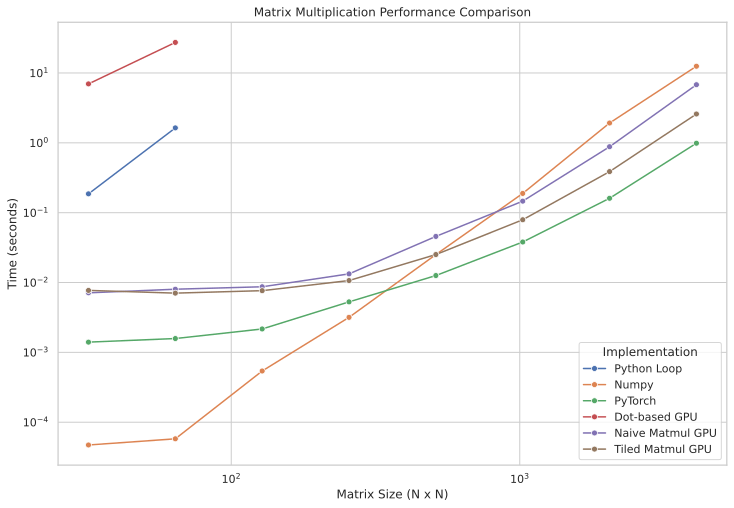

In [ ]:
df_matmul = pd.DataFrame(matmul_results)

plt.figure(figsize=(12, 8))
sns.lineplot(data=df_matmul, x='size', y='mean_time', hue='name', marker='o')
plt.title('Matrix Multiplication Performance Comparison')
plt.xlabel('Matrix Size (N x N)')
plt.ylabel('Time (seconds)')
plt.xscale('log')
plt.yscale('log')
plt.legend(title='Implementation')
plt.show()

**Выводы**:

Любые ухищрения и ускорения на CPU, которые делает Numpy, не идет ни в какое сравнение с возможностями GPU. Даже наивное исполнение на большом размере матриц побеждает Numpy.

Использование shared memory дает невероятную оптимизацию. Возможность обращения к низкоуровневым абстракциям улучшает пользовательский опыт. В очередной раз я убеждаюсь, что любой фреймворк должен оставлять протечку абстракций для продвинутого программиста.

Чтобы не происходило с железом, как бы оно не развивалось, самым главным остается именно логическое и математическое мышление самого программиста: основная идея ускорения через тайлы не состоит в shared memory. Она состоит именно в понимании того, как можно организовать матричное умножение.
И ко всем инженерным изобретениям я отношусь именно так, уважая в первую очередь, человека, который смог когда-то придумать уникальное решение.

### `Почему PyTorch все равно быстрее?`

Вы могли заметить, что даже наша самая лучшая реализация (`Tiled Matmul GPU`) все еще уступает `PyTorch` и `Numpy`. Почему так происходит?

1.  **Специализированные библиотеки (cuBLAS):** PyTorch и другие фреймворки для умножения матриц на GPU используют не свои кернелы, а вызывают функции из библиотеки **cuBLAS**. Это высокооптимизированная, написанная инженерами NVIDIA библиотека для линейной алгебры. Она учитывает все особенности конкретной архитектуры GPU (размер кэшей, количество регистров на поток, особенности планировщика варпов и т.д.).

2.  **Низкоуровневые оптимизации:** Кернелы в cuBLAS написаны на CUDA C++ и часто содержат ассемблерные вставки для достижения максимальной производительности. Они используют более продвинутые техники, чем простое тайлирование: например, более сложное управление регистрами, двойную буферизацию для скрытия задержек памяти и др.

3.  **Оверхед Numba:** Numba — это удобный инструмент, но он вносит небольшой оверхед по сравнению с кодом, написанным непосредственно на CUDA C++. Для большинства задач это не имеет значения, но в борьбе за каждый наносекунду это может играть роль.

## `Бонусы (3 балла)`

Добавьте еще скорости! За каждое ускорение на 5 процентов относительно `efficient_matmul` на матрицах размера `4096x4096` будет добавляться по 1 баллу. Для получения балла необходимо:

1) Кратко описать идею ускорения
2) Скинуть ссылку на источник, откуда был взят прием/подробно расписать идею
3) Выполнить то же тестировани, что и раньше, нариросать график
4) **Запрещается** использовать готовые решения с использованием библиотек (например, cuBLAS)

**Важно:** Нельзя специально замедлять `efficient_matmul`. Для честного сравнения в качестве времени работы `efficient_matmul` будет использоваться минимум времени работы из Вашего решения и авторского (код будет запускаться в одной среде при проверке).